In [83]:
import numpy as np
import torch
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.model_selection import train_test_split
import cv2
import random
import sys

In [85]:
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.1845, 0.1845, 0.1846], std=[0.1992, 0.1992, 0.1992])## comment this line at the begning and go calculate the mean and std
])


train_dataset = ImageFolder('./Training', transform=data_transforms)
train_size = int(0.9 * len(train_dataset))  
val_size = len(train_dataset) - train_size  
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])
test_dataset = ImageFolder('./Testing', transform=data_transforms)



In [87]:
from torchvision.datasets import ImageFolder
from torchvision.transforms import Compose, Resize, ToTensor
from torch.utils.data import random_split



##Load datasets
full_train_dataset = ImageFolder('./Training', transform=data_transforms)


##Print original size
print(f"Original train_dataset size: {len(full_train_dataset)}")



##Print sizes after splitting
print(f"Training set size after split: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")
print(f"Test set size: {len(test_dataset)}")

##Define DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)

Original train_dataset size: 5712
Training set size after split: 5140
Validation set size: 572
Test set size: 1311


In [28]:
print(f"Training set size after split: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")
print(f"Test set size: {len(test_dataset)}")

Training set size after split: 5140
Validation set size: 572
Test set size: 1311


In [30]:
## used first time only to calculate the mean and standard deviation for the dataset, remember to comment out the .Normalize() at the begining and start
##and start over after defining the specific values
#def calculate_mean_std(loader, device):
#    
#    mean = torch.zeros(3).to(device)
#    std = torch.zeros(3).to(device)
#    total_images = 0
#
#    for data in loader:
#        images = data[0]
#        images = images.to(device)
#
#        batch_size = images.size(0)
#        total_images += batch_size
#
#        # Compute mean and std for the current batch
#        # images shape: [batch_size, channels, height, width]
#        mean += images.mean([0, 2, 3]) * batch_size
#        std += images.std([0, 2, 3]) * batch_size
#
#    # Final mean and std
#    mean /= total_images
#    std /= total_images
#
#    
#    return mean.cpu(), std.cpu()
#device = torch.device("cuda:0")
#specific_values = calculate_mean_std(train_loader, device)
#print(specific_values)
#mean = specific_values[0].numpy()
#std= specific_values[1].numpy()
#print('Mean: ',mean)
#print('std: ',std)

torch.Size([32, 3, 224, 224])


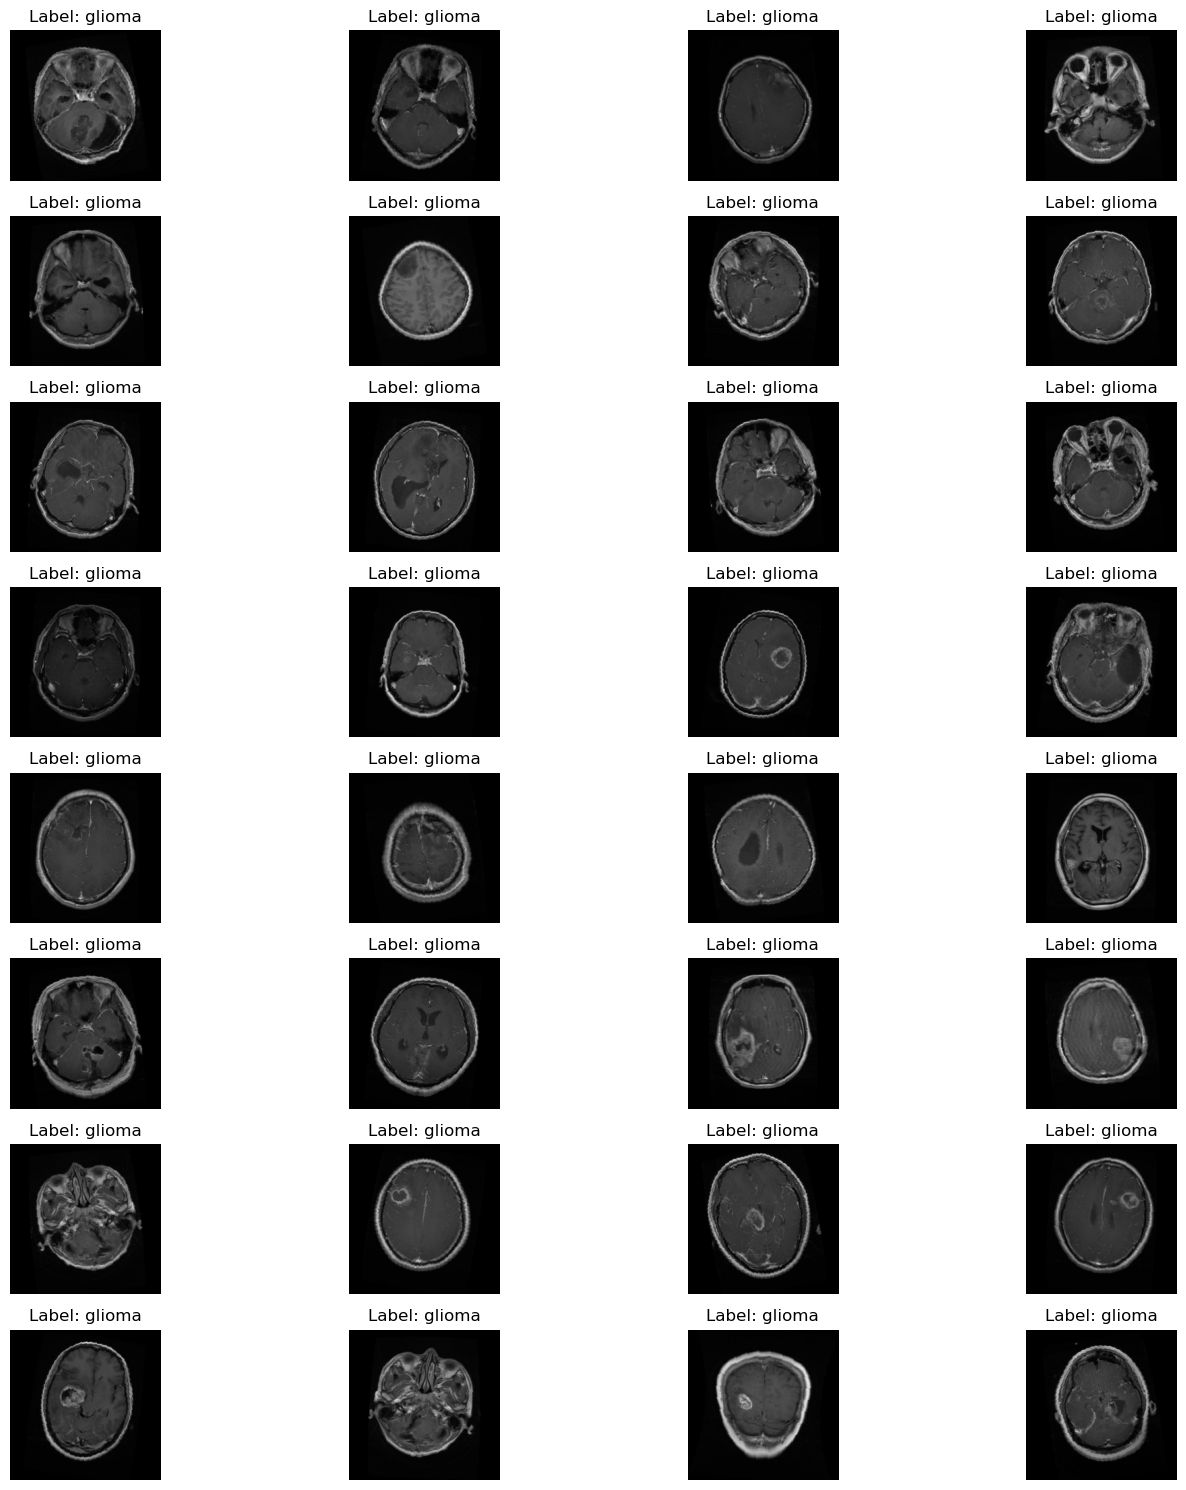

In [103]:

data_iter = iter(test_loader)
images, labels = next(data_iter)
 
# Convert images to numpy arrays and denormalize
mean = np.array([0.1845, 0.1845, 0.1846])
std = np.array([0.1992, 0.1992, 0.1992])
print(images.shape)
images = (images.numpy().transpose((0, 2, 3, 1)) * std + mean).clip(0, 1)
#images = (images.numpy().transpose((0, 2, 3, 1))).clip(0, 1) ## uncomment this if you want to see the images with normalization
# Create a grid of images
num_images = len(images)
rows = int(np.ceil(num_images / 4))
fig, axes = plt.subplots(rows, 4, figsize=(15, 15))

# Plot images with labels
for i, ax in enumerate(axes.flat):
    if i < num_images:
        ax.imshow(images[i])
        ax.set_title(f'Label: {full_train_dataset.classes[labels[i]]}')
    ax.axis('off')

plt.tight_layout()
plt.show()


In [33]:
import torch.nn as nn
import torch.nn.functional as F
class CNN(nn.Module):
    def __init__(self):
        
        super(CNN,self).__init__()
        
        ##self.conv1 = nn.Conv2d()
        ##self.conv2 = nn.conv2d()
        self.cnn_model = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.fc_model= nn.Sequential(
            nn.Linear(256 * 14 * 14, 512),  # Adjust this size based on your output shape
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, 4)
        )
    def forward(self, x):
        x = self.cnn_model(x)
            ## Since we created a 32 channel during the CNN phase, we need to flatten it before it goes to the linear phase, the following command does that
        x = x.view(x.size(0), -1) ##(32, 3, 128, 128), the -1 is responsible for flattening the array (32, 3, 128, 128) to 32 arrays idependently
                                ## then each img flattened is passed to the FC model
        x = self.fc_model(x) ## passing the flattened vector to the linear phase
        
        return x


# Initialization 

In [35]:
from torch.optim.lr_scheduler import ReduceLROnPlateau
device = torch.device("cuda:0")
model = CNN().to(device)
eta = 0.00001
loss_F = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = eta)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, verbose=True)
epoch_train_loss= []
epoch_val_loss =[]
train_accs =[]
val_accs = []


D:\software\Anaconda\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


# Training Loop

In [15]:
number_epochs = 100
highest_val_accuracy = 0.0
for epoch in range(number_epochs):
    model.train()
    train_loss = 0.0
    correct = 0
    total = 0
    for batch_idx, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad() ## to delete any cache
        outputs = model(images)
        ## now we have 32 values in the prediction and 32 values in the label, we need to merge them together
        loss = loss_F(outputs, labels)
        loss.backward() ## this computes back propagation to update the gradients
        ##the next step is to update the parameters of the model according to those gradients 
        optimizer.step()
        train_loss += loss.item()## now loss is a tensor, we need to store the value of the tensor in the losses list, .item() grabs the value of tensors
        predicted = torch.max(outputs, 1)[1]##tensor([
                                                       ##[2.3, 1.5, 0.2, 3.1],   # Scores for Sample 1
                                                       ##[0.5, 2.2, 3.3, 0.8],   # Scores for Sample 2
                                                       ##[1.1, 0.9, 2.5, 4.0]    # Scores for Sample 3])
        total = total + labels.size(0)
        correct += (predicted == labels).sum().item()
    train_accuracy = correct/total
    train_loss /=len(train_loader)
    epoch_train_loss.append(train_loss)
    train_accs.append(train_accuracy)
    
    ##validate for current epoch
    
    model.eval()
    val_loss = 0.0
    correct = 0
    total= 0
    true_labels = []
    predicted_labels = []
    with torch.no_grad(): ## just to save computational power, no need for calculating gradients
        for D, (images, labels) in enumerate(val_loader):
            images = images.to(device)
            labels = labels.to(device)
            output = model(images) 
            loss = loss_F(output, labels)
            val_loss += loss.item()
            predicted = torch.max(output, 1)[1]
            true_labels.extend(labels.cpu().numpy())
            predicted_labels.extend(predicted.cpu().numpy())
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    val_loss = val_loss / len(val_loader)
    epoch_val_loss.append(val_loss)
    val_accuracy = correct / total
    val_accs.append(val_accuracy)
    true_labels = np.array(true_labels)
    predicted_labels = np.array(predicted_labels)
    
    print(f'Epoch [{epoch+1}/{number_epochs}], '
          f'Training Loss: {train_loss:.4f}, Training Accuracy: {train_accs[-1]:.2%}, '
          f'Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accs[-1]:.2%}')
    scheduler.step(val_loss)
    if val_accuracy > highest_val_accuracy:
        highest_val_accuracy = val_accuracy  # Update the highest validation accuracy
        torch.save(model.state_dict(), 'best_3.pth')

    

Epoch [1/100], Training Loss: 1.3003, Training Accuracy: 32.52%, Validation Loss: 1.1338, Validation Accuracy: 56.08%
Epoch [2/100], Training Loss: 0.9854, Training Accuracy: 61.15%, Validation Loss: 0.8270, Validation Accuracy: 69.29%
Epoch [3/100], Training Loss: 0.8146, Training Accuracy: 67.87%, Validation Loss: 0.7234, Validation Accuracy: 70.25%
Epoch [4/100], Training Loss: 0.7440, Training Accuracy: 71.04%, Validation Loss: 0.6639, Validation Accuracy: 74.80%
Epoch [5/100], Training Loss: 0.6969, Training Accuracy: 72.53%, Validation Loss: 0.6500, Validation Accuracy: 74.37%
Epoch [6/100], Training Loss: 0.6647, Training Accuracy: 74.22%, Validation Loss: 0.6393, Validation Accuracy: 72.97%
Epoch [7/100], Training Loss: 0.6430, Training Accuracy: 74.44%, Validation Loss: 0.5950, Validation Accuracy: 76.38%
Epoch [8/100], Training Loss: 0.6222, Training Accuracy: 75.64%, Validation Loss: 0.5707, Validation Accuracy: 78.92%
Epoch [9/100], Training Loss: 0.6040, Training Accuracy:

In [15]:
accuracy = correct / total
print(f'Validation Accuracy: {accuracy:.2%}')

NameError: name 'correct' is not defined

# Now we will test the model


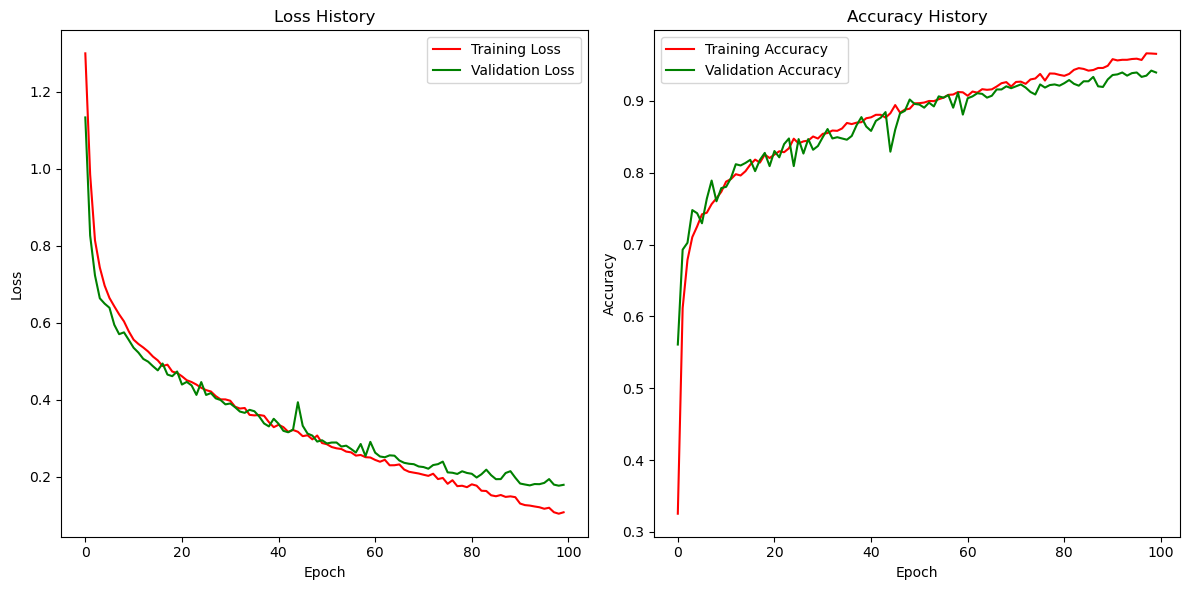

In [23]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epoch_train_loss, c='r' ,label='Training Loss')
plt.plot(epoch_val_loss, c='g', label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss History')

plt.subplot(1, 2, 2)
plt.plot(train_accs, c='r', label='Training Accuracy')
plt.plot(val_accs, c='g', label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy History')

plt.tight_layout()
plt.show()
        

In [105]:


# Get the convolutional layers from the model
no_layers = 0
conv_layers = []

In [107]:
model_children = list(model.children())
for c in model_children:
    if isinstance(c, nn.Sequential):
        for layer in c.children():
            if isinstance(layer, nn.Conv2d):
                no_layers += 1
                conv_layers.append(layer)

In [115]:
# Get an image from the training dataset

img, _ = train_dataset[533]  

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


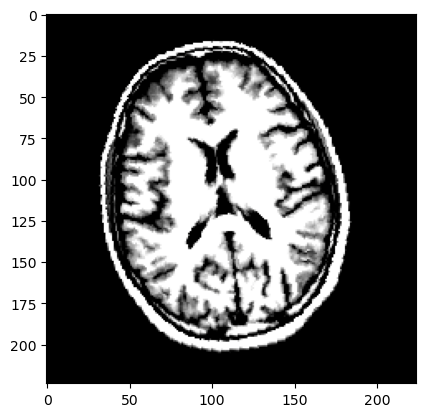

In [117]:
before = img.permute(1,2,0)
plt.imshow(before)
img, _ = train_dataset[533]

Layer  1


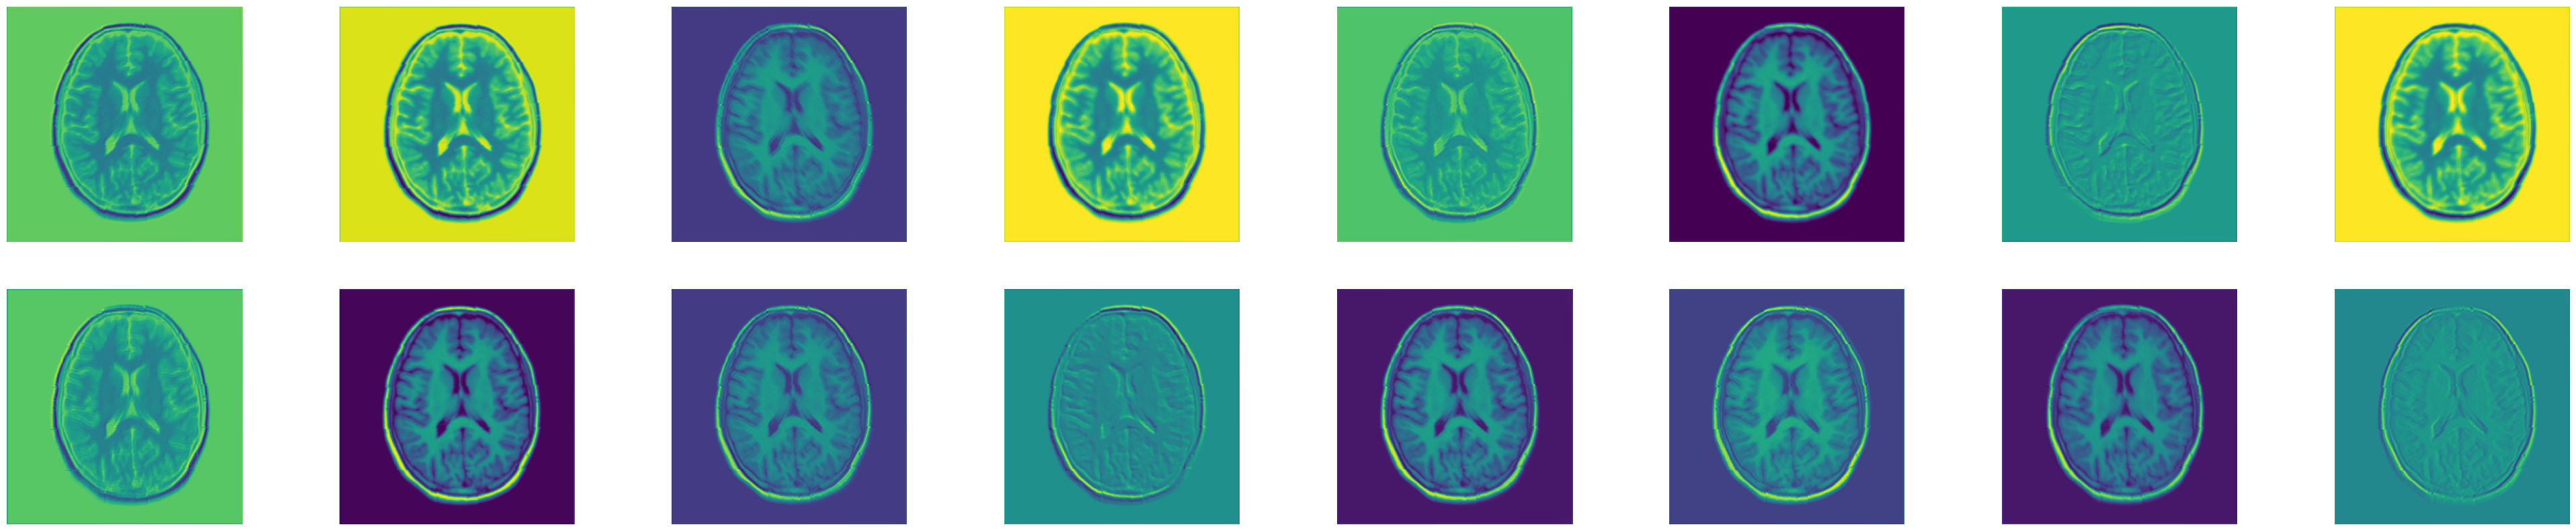

Layer  2


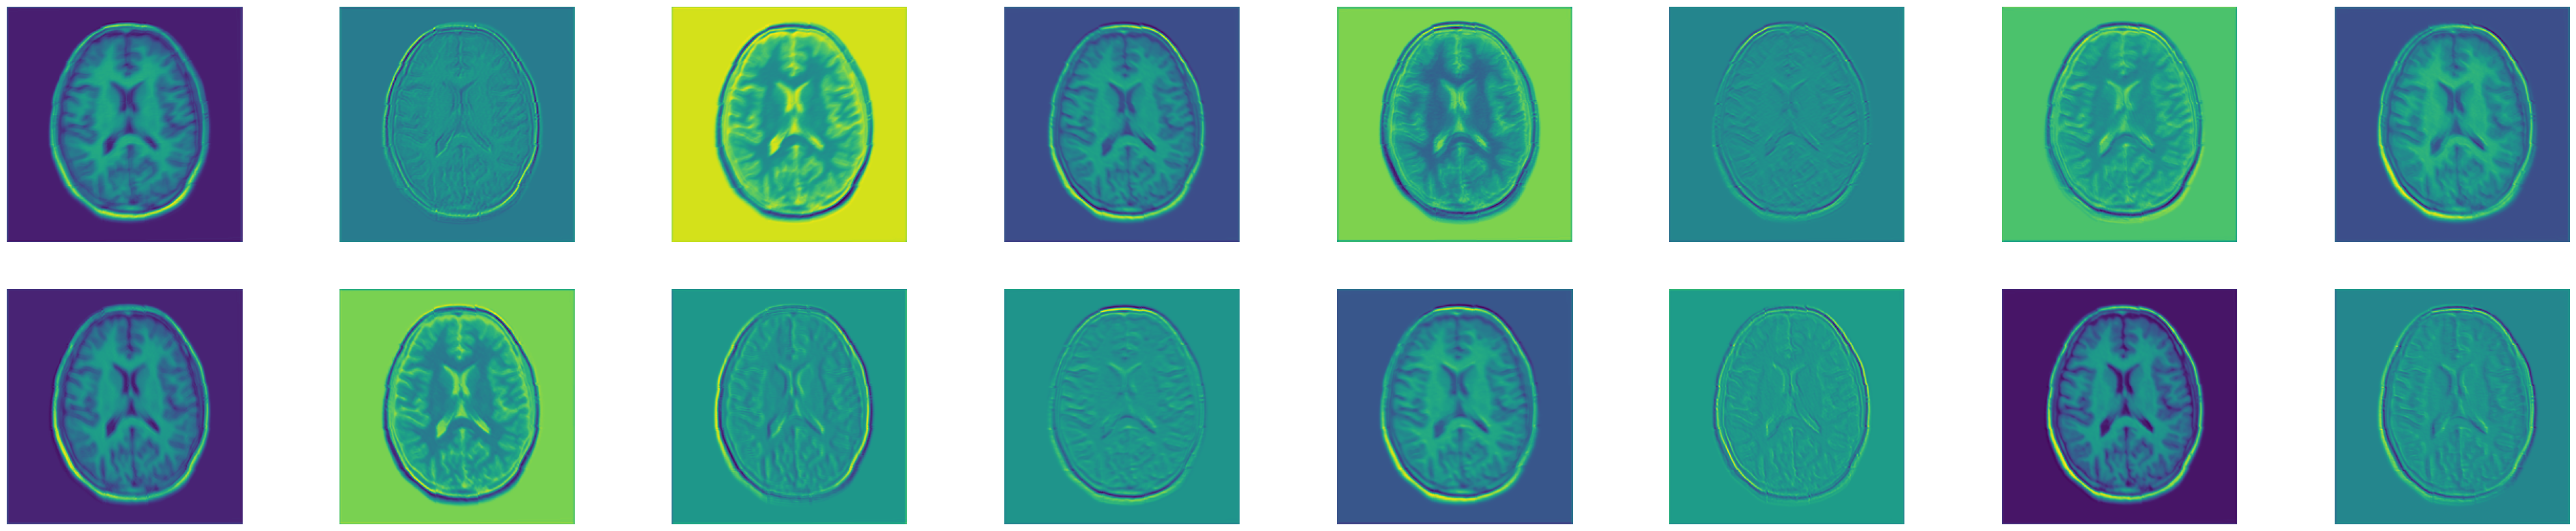

Layer  3


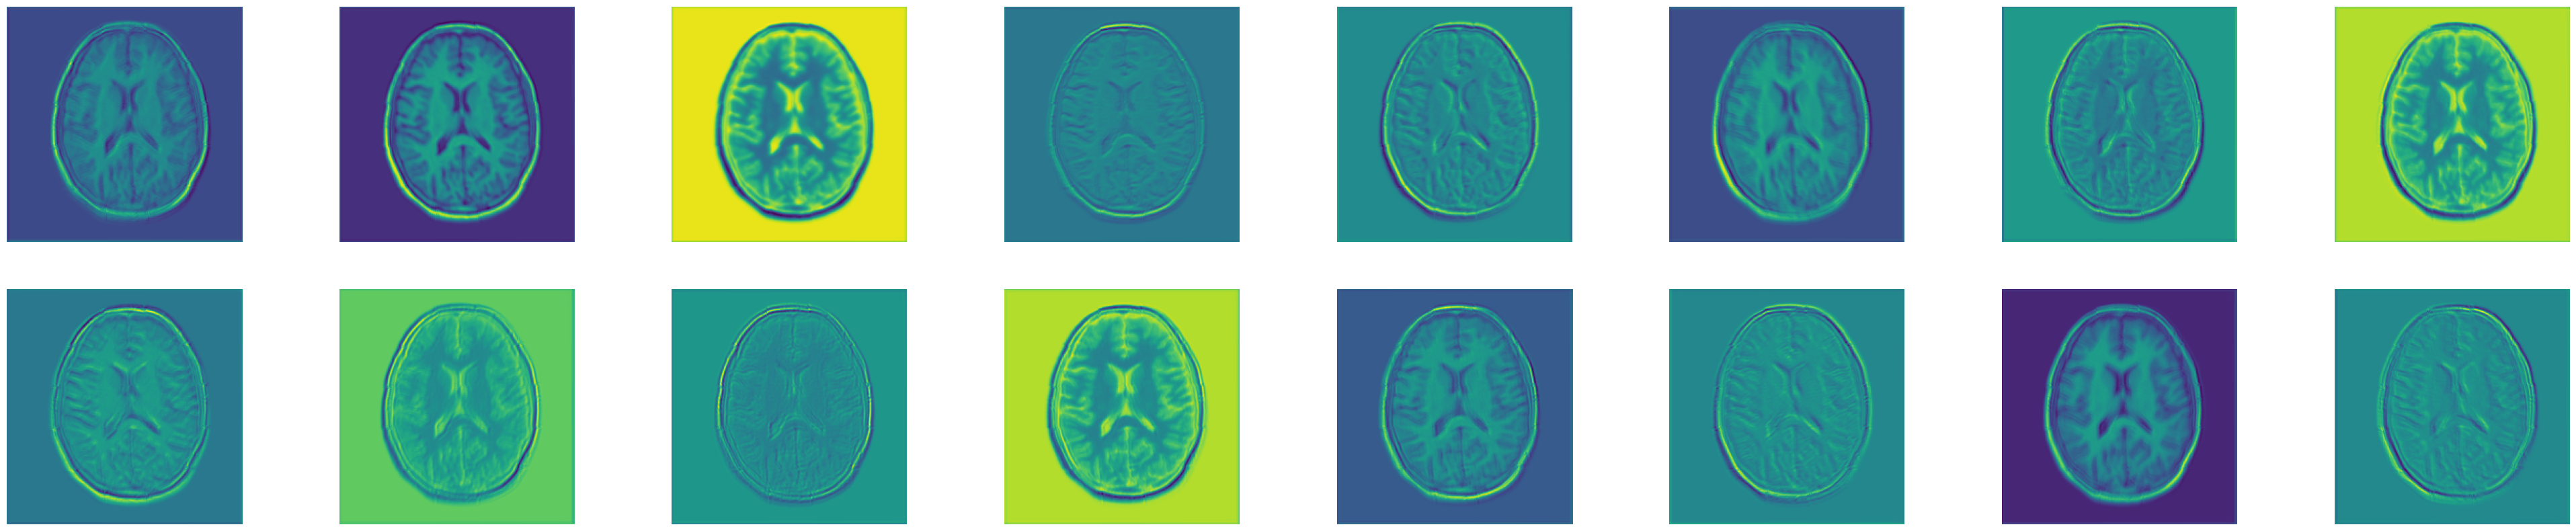

Layer  4


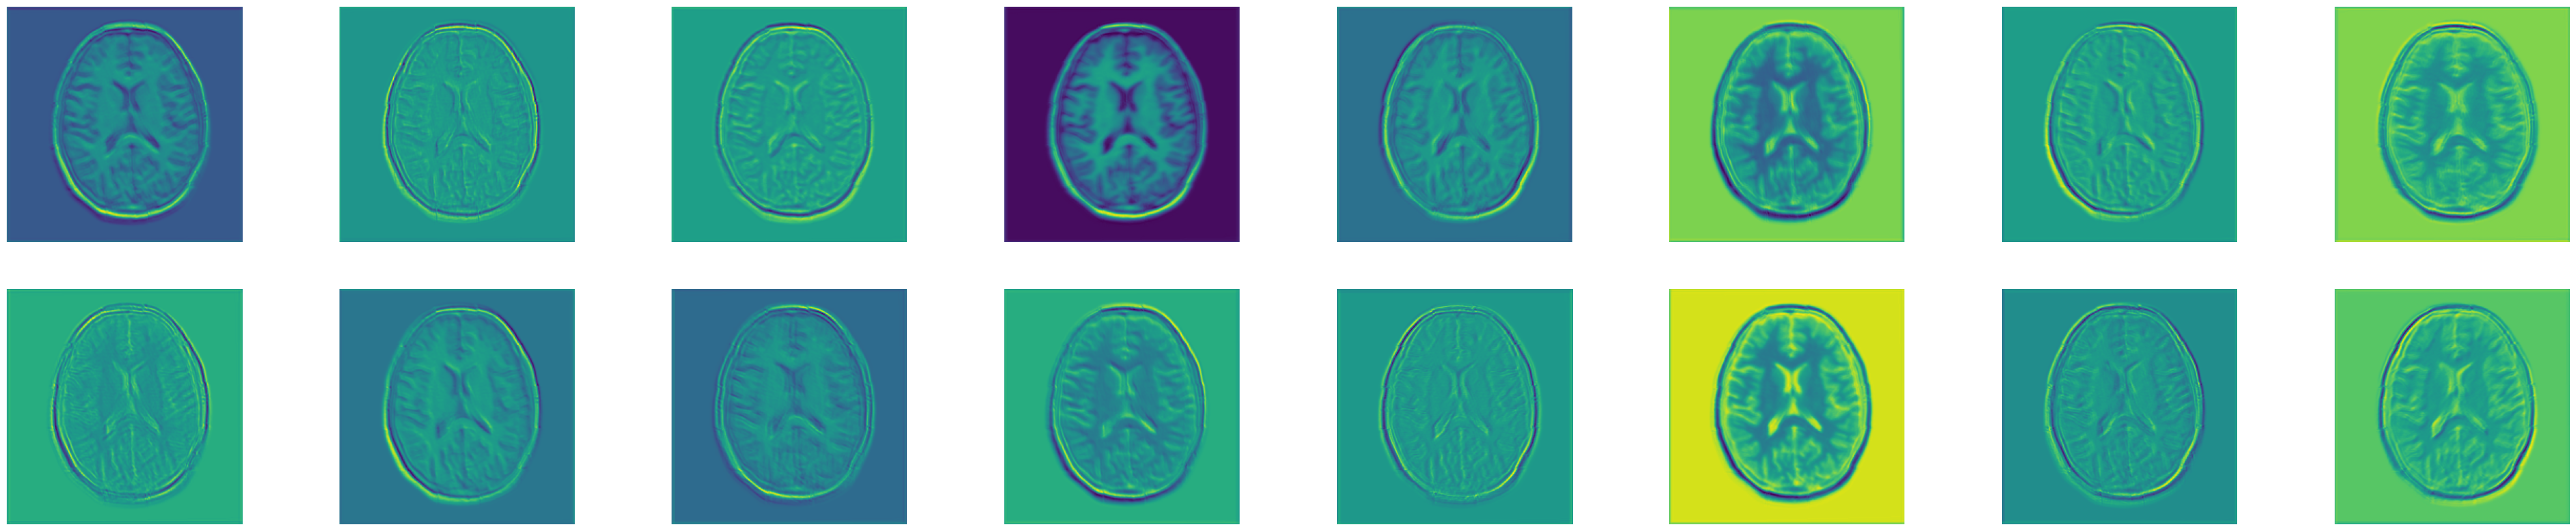

In [119]:
img = img.unsqueeze(0).to(device)  # Add batch dimension and move to device

# Pass the image through the convolutional layers to get feature maps
results = [conv_layers[0](img.float())]
for i in range(1, no_layers):
    results.append(conv_layers[i](results[-1]))

# Visualize the feature maps
for n in range(len(results)):
    plt.figure(figsize=(50, 10))
    layer_viz = results[n].squeeze()  # Remove batch dimension
    print("Layer ", n + 1)
    for i, f in enumerate(layer_viz):
        if i >= 16:  # Limit to the first 16 feature maps for visualization
            break
        plt.subplot(2, 8, i + 1)
        plt.imshow(f.detach().cpu().numpy(),cmap='viridis')  # Use a colormap for better visualization
        plt.axis("off")
    plt.show()
    plt.close()

# Tester

In [123]:
from PIL import Image

def predict_image_label(image_path, model, device='cuda:0'):
    # Set the model to evaluation mode
    model.eval()

    data_transforms = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.1845, 0.1845, 0.1846], std=[0.1992, 0.1992, 0.1992])
    ])

    # Load and preprocess the image
    image = Image.open(image_path).convert('RGB')  # Open the image and convert to RGB
    image = data_transforms(image)  # Apply transformations
    image = image.unsqueeze(0).to(device)  # Add batch dimension and move to device

    # Make the prediction
    with torch.no_grad():  # No need to calculate gradients
        output = model(image)
        _, predicted = torch.max(output, 1)  # Get the index of the max log-probability

    return predicted.item()  # Return the predicted label

In [125]:
custom_model = CNN()  
custom_model.load_state_dict(torch.load('best_3.pth'))  # Load your trained model weights
custom_model.to('cuda:0')  # Move to device


C:\Users\20112\AppData\Local\Temp\ipykernel_20536\3619129390.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  custom_model.load_state_dict(torch.load('best_3.pth'))  # Lo

CNN(
  (cnn_model): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_model): Sequential(
    (0): Linear(in_features=50176, out_features=512, bias=True)
    (1): ReLU(inplace=True)
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=512, out_features=128, bias

In [131]:
image_path = 'download.jpg'  # Replace with your image path
predicted_label_custom = predict_image_label(image_path, custom_model)
type =''
if predicted_label_custom == 0:
    type = 'Glioma'
elif predicted_label_custom == 1:
    type ='Meningioma'
elif predicted_label_custom == 2:
    type = 'No tumor'
elif predicted_label_custom == 3:
    type = 'Pituitary'
    
print(f'Predicted Label (CNN Model): {type}')

Predicted Label (CNN Model): No tumor


['glioma', 'meningioma', 'notumor', 'pituitary']

# testing

In [30]:
device = torch.device("cuda:0")
model = CNN().to(device)
model.load_state_dict(torch.load('best_3.pth'))
model.eval() 

all_predictions = []
all_labels = []

with torch.no_grad():  
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1) 
        all_predictions.extend(predicted.cpu().numpy()) 
        all_labels.extend(labels.numpy())  

C:\Users\20112\AppData\Local\Temp\ipykernel_22544\647837815.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_3.pth'))


In [31]:

all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)

# Step 4: Calculate accuracy
test_accuracy = accuracy_score(all_labels, all_predictions)
print(f'Test Accuracy: {test_accuracy:.2%}')

Test Accuracy: 92.75%


Confusion Matrix:
[[263  34   1   2]
 [ 27 259  17   3]
 [  4   3 398   0]
 [  1   3   0 296]]
Classification Report:
              precision    recall  f1-score   support

      glioma       0.89      0.88      0.88       300
  meningioma       0.87      0.85      0.86       306
     notumor       0.96      0.98      0.97       405
   pituitary       0.98      0.99      0.99       300

    accuracy                           0.93      1311
   macro avg       0.92      0.92      0.92      1311
weighted avg       0.93      0.93      0.93      1311



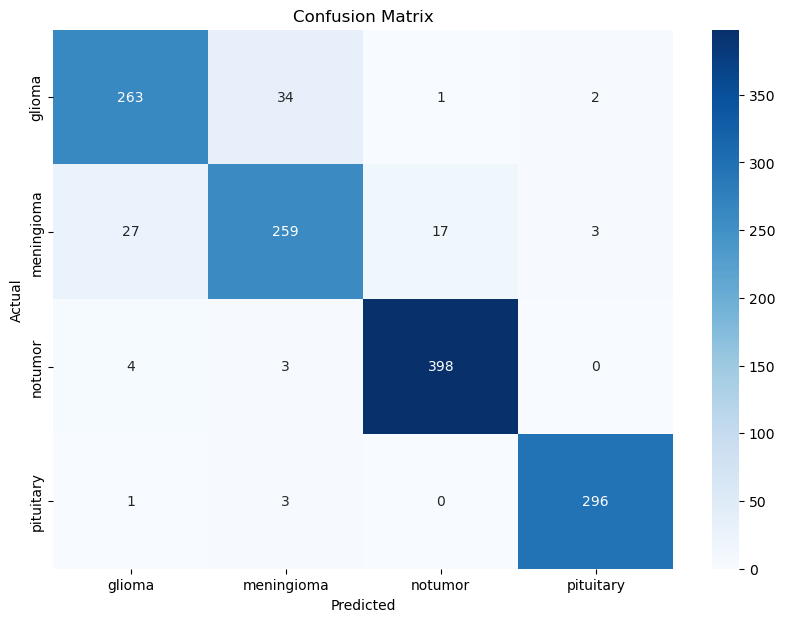

In [40]:

import matplotlib.pyplot as plt
import seaborn as sns

conf_matrix = confusion_matrix(all_labels, all_predictions)
print('Confusion Matrix:')
print(conf_matrix)


class_report = classification_report(all_labels, all_predictions, target_names=test_dataset.classes)
print('Classification Report:')
print(class_report)




plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=test_dataset.classes, yticklabels=test_dataset.classes)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()